# Second-pass preprocessing — `facebook/community-alignment-dataset`

**Goal.** Filter the *full* Community Alignment dataset (loaded fresh from Hugging Face) down to 4-way choice sets that have at least 10 annotator responses, then save clean intermediate artifacts for later linear-preference analysis.

**Inputs.** `facebook/community-alignment-dataset` from Hugging Face. The local `empirics_communityalignment/responses.parquet` is *already filtered* and is **not** used.

**Outputs.**
- `choice_sets_ge10.parquet` — one row per annotation for retained sets (annotation = a single annotator's choice on a single 4-way set, with the four response texts attached).
- `choice_set_summary_ge10.csv` — one row per retained choice set with prompt, four responses, and annotator counts.
- `pairwise_comparisons_ge10.parquet` — annotation rows expanded into 3 pairwise comparisons each: preferred vs each non-preferred sibling. Drop-in input for Bradley–Terry / BTL.

**Scope.** First-turn 4-way choice only (`first_turn_prompt`, `first_turn_response_{a,b,c,d}`, `first_turn_preferred_response`). Later turns are conditioned on the chosen first-turn response and aren't comparable as static 4-way sets — they're ignored here.

**Out of scope.** Modeling, scoring, downstream linear-preference fitting. Stops after filtered artifacts and a small audit.

## 1. Setup

In [1]:
from __future__ import annotations

import hashlib
import random
from pathlib import Path
from textwrap import shorten

import numpy as np
import pandas as pd
from datasets import load_dataset, get_dataset_config_names

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

SEED = 20260426
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# File-path configuration. Edit here, not deeper in the notebook.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "empirics_communityalignment"
DATA_DIR.mkdir(exist_ok=True)

# Filter threshold — keep choice sets with at least this many annotators.
MIN_ANNOTATORS = 10
# Whether to require non-empty first_turn_feedback. Set False to relax this filter
# and keep annotators who didn't leave a free-text comment.
REQUIRE_FEEDBACK = False

# Outputs of this notebook. "_nofb" suffix when feedback filter is relaxed,
# so the original ge10-with-feedback files don't get clobbered.
_FB_SUFFIX = "" if REQUIRE_FEEDBACK else "_nofb"
OUT_ANNOTATIONS_PARQUET = DATA_DIR / f"choice_sets_ge{MIN_ANNOTATORS}{_FB_SUFFIX}.parquet"
OUT_SUMMARY_CSV = DATA_DIR / f"choice_set_summary_ge{MIN_ANNOTATORS}{_FB_SUFFIX}.csv"

# Hugging Face dataset identifier.
HF_DATASET_ID = "facebook/community-alignment-dataset"

print("PROJECT_DIR :", PROJECT_DIR)
print("DATA_DIR    :", DATA_DIR)
print("outputs     :", OUT_ANNOTATIONS_PARQUET.name, "|", OUT_SUMMARY_CSV.name)

PROJECT_DIR : /Users/michellesi/Desktop/harvard/distortion/empirics_communityalignment
DATA_DIR    : /Users/michellesi/Desktop/harvard/distortion/empirics_communityalignment/empirics_communityalignment
outputs     : choice_sets_ge10_nofb.parquet | choice_set_summary_ge10_nofb.csv


## 2. Load dataset

Pull the full dataset directly from Hugging Face. List configs and splits before picking one so the choice is explicit.

In [3]:
def load_ca_dataset() -> pd.DataFrame:
    """Load the full Community Alignment dataset from Hugging Face as a wide-form DataFrame.

    Wide form = one row per annotation. Each row carries the prompt and all four candidate
    responses for each of up to four turns (`{turn}_response_{a,b,c,d}`), the annotator's
    chosen letter (`{turn}_preferred_response`), and annotator demographics.
    """
    print(f"Inspecting Hugging Face dataset: {HF_DATASET_ID}")
    configs = get_dataset_config_names(HF_DATASET_ID)
    print("Available configs:", configs)
    config = configs[0] if configs else None
    print(f"Using config: {config!r}")

    ds = load_dataset(HF_DATASET_ID, config) if config else load_dataset(HF_DATASET_ID)
    print("Splits:")
    for split_name in ds.keys():
        print(f"  {split_name}: {len(ds[split_name]):,} rows")

    # Pick the largest split (CA ships only `train` at present, but be robust).
    split_name = max(ds.keys(), key=lambda s: len(ds[s]))
    print(f"Selecting split: {split_name}")
    return ds[split_name].to_pandas()


raw_df = load_ca_dataset()
print(f"\nLoaded wide-form table: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} cols")

Inspecting Hugging Face dataset: facebook/community-alignment-dataset
Available configs: ['default']
Using config: 'default'
Splits:
  train: 90,256 rows
Selecting split: train

Loaded wide-form table: 90,256 rows x 45 cols


## 3. Schema inspection

Print all columns + dtypes, sample rows, and a quick uniqueness profile of the key fields.

In [4]:
def inspect_schema(df: pd.DataFrame, n_sample: int = 2) -> None:
    """Print columns, dtypes, null counts, and a few sample rows."""
    print("Columns and dtypes:")
    for col, dtype in df.dtypes.items():
        n_null = df[col].isna().sum()
        print(f"  {col:38s}  {str(dtype):12s}  nulls={n_null}")
    print(f"\nFirst {n_sample} rows:")
    display(df.head(n_sample))


inspect_schema(raw_df)

Columns and dtypes:
  conversation_id                         int64         nulls=0
  annotator_id                            int64         nulls=0
  wave                                    int64         nulls=0
  assigned_lang                           object        nulls=0
  is_pregenerated_first_prompt            bool          nulls=0
  annotator_age                           object        nulls=3618
  annotator_gender                        object        nulls=1881
  annotator_education_level               object        nulls=2724
  annotator_political                     object        nulls=0
  annotator_ethnicity                     object        nulls=0
  annotator_country                       object        nulls=0
  first_turn_prompt                       object        nulls=0
  first_turn_responses                    object        nulls=21
  first_turn_response_a                   object        nulls=21
  first_turn_response_b                   object        nulls=21
  first_

,conversation_id,annotator_id,wave,assigned_lang,is_pregenerated_first_prompt,annotator_age,annotator_gender,annotator_education_level,annotator_political,annotator_ethnicity,annotator_country,first_turn_prompt,first_turn_responses,first_turn_response_a,first_turn_response_b,...,third_turn_response_b,third_turn_response_c,third_turn_response_d,third_turn_preferred_response,third_turn_feedback,fourth_turn_prompt,fourth_turn_responses,fourth_turn_response_a,fourth_turn_response_b,fourth_turn_response_c,fourth_turn_response_d,fourth_turn_preferred_response,fourth_turn_feedback,in_balanced_subset,in_balanced_subset_10
0,1061830552573006,61575510183566,1,en,False,18-34,male,Some or complete graduate degree,Prefer not to say,Indo-Aryan,india,are EV cars better or hybrid cars?,# Response A:\nEV cars are the better choice for the environment and the future of transportation. They produce zero...,EV cars are the better choice for the environment and the future of transportation. They produce zero tailpipe emiss...,Hybrid cars offer a more realistic transition to sustainable transportation. They combine the benefits of electric m...,...,The impact of battery weight on tire life is often exaggerated. While it's true that EVs and hybrids are generally h...,"The effect of battery weight on tire lifespan is just one factor to consider among many. Driving habits, road condit...",It's essential to look at the bigger picture when evaluating the impact of battery weight on tire life. While the ad...,response_a,None,None,None,None,None,None,None,None,None,True,True
1,1740200396922271,61574885769787,1,fr,True,18-34,female,Post-secondary graduate,Somewhat left-leaning,Immigrant,france,Je planifie un voyage à la Grande Barrière de corail. Quels sont les meilleurs spots de snorkeling ?,# Response A: \n\nLa Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la pla...,"La Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la planète, offrant une ...","Pour une expérience de snorkeling unique à la Grande Barrière de corail, il est recommandé de visiter les récifs sit...",...,None,None,None,None,None,None,None,None,None,None,None,None,None,False,True


In [5]:
# Uniqueness profile of fields we care about.
for col in [
    "conversation_id",
    "annotator_id",
    "first_turn_prompt",
    "first_turn_response_a",
    "first_turn_preferred_response",
]:
    n_unique = raw_df[col].nunique(dropna=True)
    print(f"  {col:35s} unique = {n_unique:,}")

print("\nfirst_turn_preferred_response value counts:")
print(raw_df["first_turn_preferred_response"].value_counts(dropna=False))

  conversation_id                     unique = 90,256
  annotator_id                        unique = 3,603
  first_turn_prompt                   unique = 33,099
  first_turn_response_a               unique = 43,393
  first_turn_preferred_response       unique = 4

first_turn_preferred_response value counts:
response_d    31179
response_a    26849
response_b    16047
response_c    15554
None            627
Name: first_turn_preferred_response, dtype: int64


### Field-role summary

| Field | Role |
|---|---|
| `conversation_id` | Per-annotation ID. **Not** a grouping key — each row has its own `conversation_id` (uniqueness check above will confirm `nunique == nrows`). |
| `annotator_id` | Identifier of the annotator. |
| `first_turn_prompt` | Prompt text shown to the annotator. |
| `first_turn_response_a/b/c/d` | The four candidate responses (wide). |
| `first_turn_preferred_response` | The chosen response code, e.g. `response_a`. |
| `first_turn_feedback` | Free-text rationale. **Used as a row filter** (we drop annotations without it) since downstream feature extraction relies on this signal. |
| `is_pregenerated_first_prompt` | Flag for prompts drawn from the pre-generated pool. **Used as a row filter** — user-written prompts are dropped because they're one-of-a-kind and won't accumulate multi-annotator coverage. |
| `wave`, `assigned_lang`, `annotator_*` | Wave, language, demographics (kept on annotation rows for downstream use). |
| `in_balanced_subset`, `in_balanced_subset_10` | Dataset-shipped subset flags. We compute our own threshold rather than trust these flags blindly, but we'll cross-check at the end. |

### Choice-set ID — ambiguity, resolved

The dataset does not ship a column that identifies which annotations refer to the *same* prompt + 4 candidate responses. `conversation_id` is per-annotation (verified next cell). We therefore define a **content hash** key:

```
choice_set_id = sha1(first_turn_prompt | first_turn_response_a | ... | first_turn_response_d)
```

Two annotations belong to the same 4-way choice set iff their (prompt, response_a, response_b, response_c, response_d) tuple is byte-identical.

**Per-draw vs prompt-pooled (decision).** ~11.5% of prompts in CA have multiple distinct size-4 draws (each annotator gets a random 4-subset of a larger response pool, median pool size = 12). We deliberately treat each unique 4-menu as its own choice set — *per-draw*, not pooled by prompt. This keeps the menu fixed across annotators of a given choice set, which is what the downstream BTL / linear-preference setup assumes. Position shuffling within a fixed 4-set does not occur in the dataset (verified empirically), so ordered and orderless grouping yield the same partition. If you ever want to switch to prompt-pooled (Plackett-Luce on the full response pool), redefine `make_choice_set_id` to hash only the prompt and rerun.

In [6]:
# Bind expected column names. Edit this single block if the HF schema changes.
COL_PROMPT = "first_turn_prompt"
COL_RESP_A = "first_turn_response_a"
COL_RESP_B = "first_turn_response_b"
COL_RESP_C = "first_turn_response_c"
COL_RESP_D = "first_turn_response_d"
COL_CHOSEN = "first_turn_preferred_response"
COL_ANNOTATOR = "annotator_id"
COL_CONV_ID = "conversation_id"
COL_PREGENERATED = "is_pregenerated_first_prompt"
COL_FEEDBACK = "first_turn_feedback"

RESPONSE_COLS = [COL_RESP_A, COL_RESP_B, COL_RESP_C, COL_RESP_D]
CONTENT_COLS = [COL_PROMPT] + RESPONSE_COLS

EXPECTED_COLS = CONTENT_COLS + [COL_CHOSEN, COL_ANNOTATOR, COL_CONV_ID, COL_PREGENERATED, COL_FEEDBACK]
missing = [c for c in EXPECTED_COLS if c not in raw_df.columns]
if missing:
    raise KeyError(
        f"Expected columns missing from the loaded dataset: {missing}.\n"
        f"Available columns: {list(raw_df.columns)}.\n"
        "Edit the COL_* aliases above before continuing."
    )

# Confirm conversation_id is per-row (i.e., NOT a valid choice-set grouping key).
n_rows = len(raw_df)
n_conv = raw_df[COL_CONV_ID].nunique()
print(f"conversation_id uniqueness: {n_conv:,} unique / {n_rows:,} rows")
if n_conv == n_rows:
    print("-> conversation_id is per-annotation; using content-hash choice_set_id instead.")
else:
    print("-> conversation_id has duplicates: STOP and re-evaluate whether it could serve as the grouping key.")
    raise RuntimeError(
        f"conversation_id has {n_rows - n_conv} duplicate(s). The notebook assumes per-row IDs; "
        "investigate before continuing."
    )

conversation_id uniqueness: 90,256 unique / 90,256 rows
-> conversation_id is per-annotation; using content-hash choice_set_id instead.


## 4. Apply row-level filters

Two row-level filters applied **before** grouping. Both shrink the annotation pool we feed into the grouping/threshold pipeline:

- **Pregenerated first prompts only** (`is_pregenerated_first_prompt == True`). User-written prompts are each one-of-a-kind and won’t accumulate the multi-annotator coverage we need.
- **Non-empty annotator feedback** (`first_turn_feedback` not null and not whitespace-only). Downstream feature extraction depends on this rationale text; annotations without it can’t contribute.

These filters mutate `raw_df` in place. The pre-filter count is captured once in `_n_annotations_loaded`, so re-running this cell does not shift the baseline reported below or in the final report.

In [7]:
# Capture the pre-filter count exactly once, so re-running this cell is idempotent
# w.r.t. the baseline used in the final report.
if "_n_annotations_loaded" not in globals():
    _n_annotations_loaded = len(raw_df)
n_before_row_filters = _n_annotations_loaded

# Filter 1: pregenerated first prompts only. Coerce NaN -> False so missing flags drop.
mask_pregen = raw_df[COL_PREGENERATED].fillna(False).astype(bool)

# Filter 2: non-empty first_turn_feedback. NaN, empty string, and whitespace-only all drop.
feedback = raw_df[COL_FEEDBACK]
mask_has_feedback = feedback.notna() & feedback.astype(str).str.strip().ne("")

mask_keep = mask_pregen & (mask_has_feedback if REQUIRE_FEEDBACK else True)
raw_df = raw_df[mask_keep].reset_index(drop=True)

print(f"Annotations loaded                     : {n_before_row_filters:>7,}")
print(f"  with is_pregenerated_first_prompt    : {int(mask_pregen.sum()):>7,}")
print(f"  with non-empty first_turn_feedback   : {int(mask_has_feedback.sum()):>7,}  (filter {'ON' if REQUIRE_FEEDBACK else 'OFF'})")
print(f"Annotations after row filters          : {len(raw_df):>7,}")
if n_before_row_filters:
    print(f"  -> kept {100*len(raw_df)/n_before_row_filters:.1f}% of loaded annotations")


Annotations loaded                     :  90,256
  with is_pregenerated_first_prompt    :  62,295
  with non-empty first_turn_feedback   :  39,046  (filter OFF)
Annotations after row filters          :  62,295
  -> kept 69.0% of loaded annotations


## 5. Define the grouping key

**Grouping key:** `choice_set_id = sha1(prompt || response_a || response_b || response_c || response_d)`.

Invariants we then verify:
- Within a `choice_set_id`, the prompt and four candidate responses are byte-identical (trivially true by construction, but we sanity-check anyway).
- The `chosen_response` codes seen within a group are a subset of `{response_a, response_b, response_c, response_d}` (or NaN for skipped annotations).

In [8]:
def make_choice_set_id(df: pd.DataFrame) -> pd.Series:
    """SHA-1 hash of (prompt | response_a | response_b | response_c | response_d).

    Uses a NUL byte separator so concatenation collisions across columns are not possible.
    Returns a Series of hex strings aligned to `df.index`.
    """
    sep = "\x00"
    payload = df[CONTENT_COLS].fillna("").astype(str).agg(sep.join, axis=1)
    return payload.map(lambda s: hashlib.sha1(s.encode("utf-8")).hexdigest())


GROUPING_KEY = "choice_set_id"
raw_df[GROUPING_KEY] = make_choice_set_id(raw_df)
print(f"Grouping key in use: {GROUPING_KEY!r}")
print(f"Distinct choice_set_ids: {raw_df[GROUPING_KEY].nunique():,}")
print(f"Total annotations:       {len(raw_df):,}")

Grouping key in use: 'choice_set_id'
Distinct choice_set_ids: 15,608
Total annotations:       62,295


In [9]:
def validate_grouping_invariants(df: pd.DataFrame, group_key: str = GROUPING_KEY) -> None:
    """Sanity-check that content is constant within a group and chosen codes are well-formed."""
    grouped = df.groupby(group_key, sort=False)

    # 1. Content invariance (trivially expected since the key IS a content hash).
    for col in CONTENT_COLS:
        n_unique = grouped[col].nunique(dropna=False)
        bad = n_unique[n_unique != 1]
        if not bad.empty:
            raise AssertionError(
                f"{len(bad)} groups have non-unique {col} "
                f"(suggests a hash collision — should be impossible). Examples: {bad.head(3).to_dict()}"
            )

    # 2. Chosen-response codes are a subset of expected letters (NaN allowed for skips).
    valid_codes = {"response_a", "response_b", "response_c", "response_d"}
    seen_codes = set(df[COL_CHOSEN].dropna().unique())
    unexpected = seen_codes - valid_codes
    if unexpected:
        raise AssertionError(f"Unexpected chosen codes in {COL_CHOSEN}: {unexpected}")

    print("Invariants OK:")
    print(f"  - all of {CONTENT_COLS} are constant within each {group_key}")
    print(f"  - chosen codes ⊆ {sorted(valid_codes)} (NaN allowed for skipped annotations)")


validate_grouping_invariants(raw_df)

Invariants OK:
  - all of ['first_turn_prompt', 'first_turn_response_a', 'first_turn_response_b', 'first_turn_response_c', 'first_turn_response_d'] are constant within each choice_set_id
  - chosen codes ⊆ ['response_a', 'response_b', 'response_c', 'response_d'] (NaN allowed for skipped annotations)


## 6. Count annotator responses per choice set

In [10]:
def count_annotations_per_set(df: pd.DataFrame, group_key: str = GROUPING_KEY) -> pd.DataFrame:
    """Per-choice-set counts of annotations and unique annotators.

    Annotations with NaN `chosen_response` are *not* dropped here — they still represent
    an annotator who saw the choice set. Drop them downstream if you only want labeled rows.
    """
    return (
        df.groupby(group_key, sort=False)
        .agg(
            n_annotations=(COL_ANNOTATOR, "size"),
            n_unique_annotators=(COL_ANNOTATOR, "nunique"),
            n_labeled_annotations=(COL_CHOSEN, lambda s: s.notna().sum()),
        )
        .reset_index()
    )


set_counts_df = count_annotations_per_set(raw_df)
print(f"Total annotations    : {len(raw_df):,}")
print(f"Unique choice sets   : {len(set_counts_df):,}")
display(set_counts_df.head())

Total annotations    : 62,295
Unique choice sets   : 15,608


,choice_set_id,n_annotations,n_unique_annotators,n_labeled_annotations
0,8bc3cf453552b0c227bcf9346f0637f30c2f637c,14,14,14
1,42bebcab25df1288a0592b9a84741267f71d4e36,10,10,10
2,9d6a1af9296e920b3aade362b7418b9acb37a3dd,15,15,15
3,8069c3dfaff7af671a0848b3a1b1bf3154e05f5d,13,13,13
4,61c63d509c1798210416c8efca201bbd258e4b8c,17,17,17


In [11]:
print("n_annotations summary:")
print(set_counts_df["n_annotations"].describe())
print("\nValue counts (truncated to first 25 bins):")
print(set_counts_df["n_annotations"].value_counts().sort_index().head(25))

n_annotations summary:
count    15608.000000
mean         3.991222
std          7.106454
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         38.000000
Name: n_annotations, dtype: float64

Value counts (truncated to first 25 bins):
1     12680
2        60
3        48
4        22
5        21
6        26
7        24
8        50
9        71
10       88
11      130
12      162
13      239
14      304
15      326
16      292
17      251
18      129
19       71
20       15
21        2
23        8
24       11
25       15
26       25
Name: n_annotations, dtype: int64


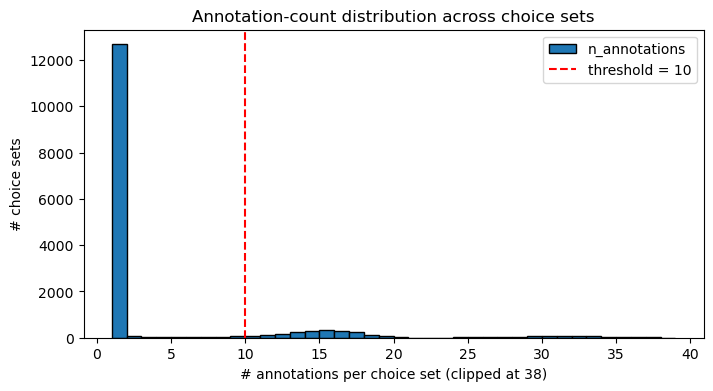

In [12]:
# Histogram, capped at a reasonable upper bin so the long tail doesn't dominate.
max_count = int(set_counts_df["n_annotations"].max())
upper = min(max_count, 40)
ax = set_counts_df["n_annotations"].clip(upper=upper).plot.hist(
    bins=range(1, upper + 2),
    figsize=(8, 4),
    edgecolor="black",
)
ax.axvline(MIN_ANNOTATORS, color="red", linestyle="--", label=f"threshold = {MIN_ANNOTATORS}")
ax.set_xlabel(f"# annotations per choice set (clipped at {upper})")
ax.set_ylabel("# choice sets")
ax.set_title("Annotation-count distribution across choice sets")
ax.legend();

## 7. Filter retained choice sets

Keep choice sets with at least `MIN_ANNOTATORS` (= 10) annotator responses, then save:

- `choice_sets_ge10.parquet` — annotation rows for retained sets, with response_1..response_4 attached as wide columns.
- `choice_set_summary_ge10.csv` — one row per retained choice set with prompt, four responses, and counts.

In [13]:
# A wide table of the four response texts per choice set, renamed response_1..4.
# response_i corresponds to the alphabetical position (a -> 1, b -> 2, c -> 3, d -> 4).
responses_wide_df = (
    raw_df.drop_duplicates(subset=[GROUPING_KEY])
    .set_index(GROUPING_KEY)[CONTENT_COLS]
    .rename(
        columns={
            COL_PROMPT: "prompt_text",
            COL_RESP_A: "response_1",
            COL_RESP_B: "response_2",
            COL_RESP_C: "response_3",
            COL_RESP_D: "response_4",
        }
    )
    .reset_index()
    .rename(columns={GROUPING_KEY: "choice_set_id"})
)
display(responses_wide_df.head(2))

,choice_set_id,prompt_text,response_1,response_2,response_3,response_4
0,8bc3cf453552b0c227bcf9346f0637f30c2f637c,Je planifie un voyage à la Grande Barrière de corail. Quels sont les meilleurs spots de snorkeling ?,"La Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la planète, offrant une ...","Pour une expérience de snorkeling unique à la Grande Barrière de corail, il est recommandé de visiter les récifs sit...",L'expérience de snorkeling à la Grande Barrière de corail peut être encore plus enrichissante en explorant les récif...,La Grande Barrière de corail est un endroit incroyable ! Les meilleurs spots de snorkeling incluent :\n\n* Le récif ...
1,42bebcab25df1288a0592b9a84741267f71d4e36,"Qual è la trama del romanzo ""Hunger Games""?","La trama del romanzo ""Hunger Games"" si svolge in un futuro post-apocalittico, in un luogo chiamato Panem. Il governo...","Il romanzo ""Hunger Games"" esplora temi come la ribellione, la sopravvivenza e la critica alla società moderna. La tr...","La trama del romanzo ""Hunger Games"" è un'esplorazione della psicologia umana e della dinamica di potere in una socie...","La trama del romanzo ""Hunger Games"" di Suzanne Collins è ambientata in un futuro distopico dove il Nord America è st..."


In [14]:
retained_ids_set = set(
    set_counts_df.loc[set_counts_df["n_annotations"] >= MIN_ANNOTATORS, GROUPING_KEY]
)
print(f"Retained choice sets: {len(retained_ids_set):,} of {len(set_counts_df):,}")

summary_retained_df = (
    set_counts_df[set_counts_df[GROUPING_KEY].isin(retained_ids_set)]
    .rename(columns={GROUPING_KEY: "choice_set_id"})
    .merge(responses_wide_df, on="choice_set_id", how="left")
    [[
        "choice_set_id",
        "prompt_text",
        "n_annotations",
        "n_unique_annotators",
        "response_1",
        "response_2",
        "response_3",
        "response_4",
    ]]
    .reset_index(drop=True)
)
display(summary_retained_df.head(3))

Retained choice sets: 2,606 of 15,608


,choice_set_id,prompt_text,n_annotations,n_unique_annotators,response_1,response_2,response_3,response_4
0,8bc3cf453552b0c227bcf9346f0637f30c2f637c,Je planifie un voyage à la Grande Barrière de corail. Quels sont les meilleurs spots de snorkeling ?,14,14,"La Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la planète, offrant une ...","Pour une expérience de snorkeling unique à la Grande Barrière de corail, il est recommandé de visiter les récifs sit...",L'expérience de snorkeling à la Grande Barrière de corail peut être encore plus enrichissante en explorant les récif...,La Grande Barrière de corail est un endroit incroyable ! Les meilleurs spots de snorkeling incluent :\n\n* Le récif ...
1,42bebcab25df1288a0592b9a84741267f71d4e36,"Qual è la trama del romanzo ""Hunger Games""?",10,10,"La trama del romanzo ""Hunger Games"" si svolge in un futuro post-apocalittico, in un luogo chiamato Panem. Il governo...","Il romanzo ""Hunger Games"" esplora temi come la ribellione, la sopravvivenza e la critica alla società moderna. La tr...","La trama del romanzo ""Hunger Games"" è un'esplorazione della psicologia umana e della dinamica di potere in una socie...","La trama del romanzo ""Hunger Games"" di Suzanne Collins è ambientata in un futuro distopico dove il Nord America è st..."
2,9d6a1af9296e920b3aade362b7418b9acb37a3dd,Você pode me ajudar a encontrar um lugar tranquilo nas Blue Ridge Mountains para fazer caminhadas e relaxar?,15,15,As montanhas Blue Ridge oferecem uma variedade de opções para caminhadas e relaxamento. Uma das áreas mais tranquila...,"A região das Blue Ridge Mountains é um destino perfeito para quem busca natureza, tranquilidade e atividades ao ar l...","Para uma experiência verdadeiramente única e tranquila nas Blue Ridge Mountains, considere explorar áreas menos conh...","Sim, claro! As Blue Ridge Mountains oferecem muitas opções para caminhadas e relaxamento. Algumas sugestões incluem:..."


In [15]:
# Annotation-level retained table. One row per (choice_set, annotator), with the four
# candidate response texts attached as response_1..4 plus annotator demographics that
# downstream linear-preference work will likely want to slice on.
demographic_cols = [
    c for c in (
        "wave",
        "assigned_lang",
        "annotator_age",
        "annotator_gender",
        "annotator_education_level",
        "annotator_political",
        "annotator_ethnicity",
        "annotator_country",
        "first_turn_feedback",
        "in_balanced_subset",
        "in_balanced_subset_10",
    )
    if c in raw_df.columns
]

retained_annotations_df = (
    raw_df[raw_df[GROUPING_KEY].isin(retained_ids_set)]
    .rename(
        columns={
            GROUPING_KEY: "choice_set_id",
            COL_ANNOTATOR: "annotator_id",
            COL_CHOSEN: "chosen_response",
            COL_CONV_ID: "conversation_id",
        }
    )
    .merge(responses_wide_df, on="choice_set_id", how="left", suffixes=("", "_dup"))
)
# After the merge, prompt_text/response_1..4 come from the wide table; drop any duplicated
# raw columns so the saved file has a single canonical version.
drop_dups = [c for c in retained_annotations_df.columns if c.endswith("_dup")]
retained_annotations_df = retained_annotations_df.drop(columns=drop_dups + CONTENT_COLS)

annotation_cols = [
    "choice_set_id",
    "conversation_id",
    "annotator_id",
    "prompt_text",
    "chosen_response",
    "response_1",
    "response_2",
    "response_3",
    "response_4",
    *demographic_cols,
]
annotation_cols = [c for c in annotation_cols if c in retained_annotations_df.columns]
retained_annotations_df = retained_annotations_df[annotation_cols].reset_index(drop=True)
display(retained_annotations_df.head(3))

,choice_set_id,conversation_id,annotator_id,prompt_text,chosen_response,response_1,response_2,response_3,response_4,wave,assigned_lang,annotator_age,annotator_gender,annotator_education_level,annotator_political,annotator_ethnicity,annotator_country,first_turn_feedback,in_balanced_subset,in_balanced_subset_10
0,8bc3cf453552b0c227bcf9346f0637f30c2f637c,1740200396922271,61574885769787,Je planifie un voyage à la Grande Barrière de corail. Quels sont les meilleurs spots de snorkeling ?,response_d,"La Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la planète, offrant une ...","Pour une expérience de snorkeling unique à la Grande Barrière de corail, il est recommandé de visiter les récifs sit...",L'expérience de snorkeling à la Grande Barrière de corail peut être encore plus enrichissante en explorant les récif...,La Grande Barrière de corail est un endroit incroyable ! Les meilleurs spots de snorkeling incluent :\n\n* Le récif ...,1,fr,18-34,female,Post-secondary graduate,Somewhat left-leaning,Immigrant,france,None,False,True
1,42bebcab25df1288a0592b9a84741267f71d4e36,663596853320456,61575115079212,"Qual è la trama del romanzo ""Hunger Games""?",response_d,"La trama del romanzo ""Hunger Games"" si svolge in un futuro post-apocalittico, in un luogo chiamato Panem. Il governo...","Il romanzo ""Hunger Games"" esplora temi come la ribellione, la sopravvivenza e la critica alla società moderna. La tr...","La trama del romanzo ""Hunger Games"" è un'esplorazione della psicologia umana e della dinamica di potere in una socie...","La trama del romanzo ""Hunger Games"" di Suzanne Collins è ambientata in un futuro distopico dove il Nord America è st...",1,it,18-34,male,Post-secondary graduate,I don't think of myself in this way,Italian,italy,None,False,True
2,9d6a1af9296e920b3aade362b7418b9acb37a3dd,1309050483489493,61574934126943,Você pode me ajudar a encontrar um lugar tranquilo nas Blue Ridge Mountains para fazer caminhadas e relaxar?,response_d,As montanhas Blue Ridge oferecem uma variedade de opções para caminhadas e relaxamento. Uma das áreas mais tranquila...,"A região das Blue Ridge Mountains é um destino perfeito para quem busca natureza, tranquilidade e atividades ao ar l...","Para uma experiência verdadeiramente única e tranquila nas Blue Ridge Mountains, considere explorar áreas menos conh...","Sim, claro! As Blue Ridge Mountains oferecem muitas opções para caminhadas e relaxamento. Algumas sugestões incluem:...",1,pt,35-45,male,Post-secondary graduate,Somewhat left-leaning,White,brazil,None,True,True


In [16]:
# Save outputs.
retained_annotations_df.to_parquet(OUT_ANNOTATIONS_PARQUET, index=False)
summary_retained_df.to_csv(OUT_SUMMARY_CSV, index=False)
print("Wrote:")
print(f"  {OUT_ANNOTATIONS_PARQUET}  ({len(retained_annotations_df):,} rows)")
print(f"  {OUT_SUMMARY_CSV}  ({len(summary_retained_df):,} rows)")

Wrote:
  /Users/michellesi/Desktop/harvard/distortion/empirics_communityalignment/empirics_communityalignment/choice_sets_ge10_nofb.parquet  (47,795 rows)
  /Users/michellesi/Desktop/harvard/distortion/empirics_communityalignment/empirics_communityalignment/choice_set_summary_ge10_nofb.csv  (2,606 rows)


## 8. Build pairwise comparisons (3 per annotation)

For Bradley–Terry / BTL modelling we need pairwise comparisons, not 4-way preferences. Each retained annotation (one annotator's choice from A/B/C/D) implies exactly 3 pairwise comparisons: preferred vs each of the 3 non-preferred siblings.

**Output:** `pairwise_comparisons_ge10.parquet` with columns

```
choice_set_id, conversation_id, annotator_id, prompt_text,
preferred_letter, preferred_text, other_letter, other_text,
<demographics: wave, assigned_lang, annotator_age, …>
```

Each row carries an implicit label `y = 1` (preferred wins). When fitting BTL, randomly flip half the rows' sign + label to balance the two-class problem (this is the `_make_two_class` helper used in `empirics_CA_pca.ipynb` and the kidney/MM notebooks).

In [17]:
# ── Build pairwise comparisons (3 per annotation) ─────────────────────────
# Each retained annotation encodes one 4-way preference. Expand into 3 pairwise
# rows: preferred response vs each of the 3 non-preferred siblings. This is the
# standard reduction used downstream for Bradley–Terry / BTL.

OUT_PAIRWISE_PARQUET = DATA_DIR / f"pairwise_comparisons_ge{MIN_ANNOTATORS}{_FB_SUFFIX}.parquet"

LETTER_TO_RESPONSE_COL = {
    "A": "response_1", "B": "response_2", "C": "response_3", "D": "response_4",
}
LETTER_TO_IDX = {"A": 0, "B": 1, "C": 2, "D": 3}


def normalize_choice_letter(s: object) -> str:
    """`response_d` / `D` / `d` -> `D`. Returns '' for null / unrecognized."""
    if not isinstance(s, str):
        return ""
    s = s.strip().upper().replace("RESPONSE_", "").replace("RESPONSE ", "")
    return s if s in LETTER_TO_RESPONSE_COL else ""


pw_src = retained_annotations_df.copy()
pw_src["preferred_letter"] = pw_src["chosen_response"].map(normalize_choice_letter)
n_dropped = (pw_src["preferred_letter"] == "").sum()
print(f"Dropped {n_dropped:,} annotations with null/invalid chosen_response")
pw_src = pw_src[pw_src["preferred_letter"] != ""].reset_index(drop=True)

# Vectorized lookup of preferred_text from response_1..response_4 by letter index.
response_cols = ["response_1", "response_2", "response_3", "response_4"]
pref_idx_arr = pw_src["preferred_letter"].map(LETTER_TO_IDX).to_numpy()
resp_arr     = pw_src[response_cols].to_numpy()
pw_src["preferred_text"] = resp_arr[np.arange(len(pw_src)), pref_idx_arr]

# For each non-preferred letter, build a sub-frame of (preferred-vs-other) and concat.
parts = []
for o_letter, o_col in LETTER_TO_RESPONSE_COL.items():
    sub = pw_src[pw_src["preferred_letter"] != o_letter].copy()
    sub["other_letter"] = o_letter
    sub["other_text"]   = sub[o_col]
    parts.append(sub)
pairwise_df = pd.concat(parts, ignore_index=True)

# Defensive drop in case any candidate text was null.
n_null_other = pairwise_df["other_text"].isna().sum()
if n_null_other:
    print(f"Dropping {n_null_other:,} rows with null other_text")
    pairwise_df = pairwise_df[pairwise_df["other_text"].notna()].reset_index(drop=True)

# Order columns: identifiers, then the pair, then demographics.
pairwise_cols = [
    "choice_set_id", "conversation_id", "annotator_id", "prompt_text",
    "preferred_letter", "preferred_text", "other_letter", "other_text",
    *demographic_cols,
]
pairwise_cols = [c for c in pairwise_cols if c in pairwise_df.columns]
pairwise_df = pairwise_df[pairwise_cols].reset_index(drop=True)

print(f"Pairwise rows: {len(pairwise_df):,}  "
      f"(expected ~3 x {len(pw_src):,} = {3 * len(pw_src):,})")
print("Sanity:")
print(f"  unique annotators        : {pairwise_df['annotator_id'].nunique():,}")
print(f"  unique choice sets       : {pairwise_df['choice_set_id'].nunique():,}")
print(f"  rows per (annotator,set) : "
      f"{int(pairwise_df.groupby(['annotator_id','choice_set_id']).size().mode().iloc[0])} (modal)")
print("\npreferred_letter distribution (1 row per annotation):")
print(pairwise_df.drop_duplicates(['annotator_id', 'choice_set_id'])['preferred_letter']
                 .value_counts().sort_index().to_string())

pairwise_df.to_parquet(OUT_PAIRWISE_PARQUET, index=False)
print(f"\nWrote: {OUT_PAIRWISE_PARQUET}  ({len(pairwise_df):,} rows x {pairwise_df.shape[1]} cols)")
display(pairwise_df.head(3))

Dropped 0 annotations with null/invalid chosen_response
Pairwise rows: 143,385  (expected ~3 x 47,795 = 143,385)
Sanity:
  unique annotators        : 2,868
  unique choice sets       : 2,606
  rows per (annotator,set) : 3 (modal)

preferred_letter distribution (1 row per annotation):
A    12071
B     6855
C     7217
D    21631

Wrote: /Users/michellesi/Desktop/harvard/distortion/empirics_communityalignment/empirics_communityalignment/pairwise_comparisons_ge10_nofb.parquet  (143,385 rows x 19 cols)


,choice_set_id,conversation_id,annotator_id,prompt_text,preferred_letter,preferred_text,other_letter,other_text,wave,assigned_lang,annotator_age,annotator_gender,annotator_education_level,annotator_political,annotator_ethnicity,annotator_country,first_turn_feedback,in_balanced_subset,in_balanced_subset_10
0,8bc3cf453552b0c227bcf9346f0637f30c2f637c,1740200396922271,61574885769787,Je planifie un voyage à la Grande Barrière de corail. Quels sont les meilleurs spots de snorkeling ?,D,La Grande Barrière de corail est un endroit incroyable ! Les meilleurs spots de snorkeling incluent :\n\n* Le récif ...,A,"La Grande Barrière de corail est l'un des écosystèmes les plus diversifiés et fascinants de la planète, offrant une ...",1,fr,18-34,female,Post-secondary graduate,Somewhat left-leaning,Immigrant,france,None,False,True
1,42bebcab25df1288a0592b9a84741267f71d4e36,663596853320456,61575115079212,"Qual è la trama del romanzo ""Hunger Games""?",D,"La trama del romanzo ""Hunger Games"" di Suzanne Collins è ambientata in un futuro distopico dove il Nord America è st...",A,"La trama del romanzo ""Hunger Games"" si svolge in un futuro post-apocalittico, in un luogo chiamato Panem. Il governo...",1,it,18-34,male,Post-secondary graduate,I don't think of myself in this way,Italian,italy,None,False,True
2,9d6a1af9296e920b3aade362b7418b9acb37a3dd,1309050483489493,61574934126943,Você pode me ajudar a encontrar um lugar tranquilo nas Blue Ridge Mountains para fazer caminhadas e relaxar?,D,"Sim, claro! As Blue Ridge Mountains oferecem muitas opções para caminhadas e relaxamento. Algumas sugestões incluem:...",A,As montanhas Blue Ridge oferecem uma variedade de opções para caminhadas e relaxamento. Uma das áreas mais tranquila...,1,pt,35-45,male,Post-secondary graduate,Somewhat left-leaning,White,brazil,None,True,True


## 9. Audit retained sets

Sample a small number of retained choice sets and inspect them by hand: prompt, four candidates, and the empirical distribution of annotator choices.

In [18]:
def sample_retained_sets(
    summary: pd.DataFrame,
    annotations: pd.DataFrame,
    n: int = 12,
    seed: int = SEED,
) -> list[dict]:
    """Build audit records for n randomly chosen retained sets."""
    n = min(n, len(summary))
    sampled = summary.sample(n=n, random_state=seed)
    records = []
    for _, row in sampled.iterrows():
        cs_id = row["choice_set_id"]
        ann_subset = annotations[annotations["choice_set_id"] == cs_id]
        choice_counts = ann_subset["chosen_response"].value_counts(dropna=False).to_dict()
        records.append(
            {
                "choice_set_id": cs_id,
                "prompt": shorten(str(row["prompt_text"]), width=160, placeholder=" ..."),
                "n_annotations": int(row["n_annotations"]),
                "n_unique_annotators": int(row["n_unique_annotators"]),
                "response_1": shorten(str(row["response_1"]), width=140, placeholder=" ..."),
                "response_2": shorten(str(row["response_2"]), width=140, placeholder=" ..."),
                "response_3": shorten(str(row["response_3"]), width=140, placeholder=" ..."),
                "response_4": shorten(str(row["response_4"]), width=140, placeholder=" ..."),
                "choice_counts": choice_counts,
            }
        )
    return records


audit_records = sample_retained_sets(summary_retained_df, retained_annotations_df, n=12)
for rec in audit_records:
    print("=" * 88)
    print(f"choice_set_id        : {rec['choice_set_id']}")
    print(f"n_annotations        : {rec['n_annotations']}")
    print(f"n_unique_annotators  : {rec['n_unique_annotators']}")
    print(f"prompt               : {rec['prompt']}")
    for i in range(1, 5):
        print(f"response_{i}           : {rec[f'response_{i}']}")
    print(f"choice_counts        : {rec['choice_counts']}")

choice_set_id        : eb95be4636a4fa69a228fbbedb846f1e601d7de0
n_annotations        : 36
n_unique_annotators  : 36
prompt               : I'm looking for a fun and easy DIY beauty treatment to do at home, can you suggest some options?
response_1           : Consider a soothing face mask made from natural ingredients like honey, avocado, and oatmeal. These ingredients are known for their ...
response_2           : For a more vibrant and glowing skin, try a homemade sugar scrub. Mix together sugar, coconut oil, and a squeeze of fresh lemon juice to ...
response_3           : Indulge in a relaxing and nourishing hair treatment by creating a deep conditioning mask using ingredients like olive oil, shea butter, ...
response_4           : Try a face mask made from honey and avocado, or a sugar scrub for exfoliating. You can also make a hair mask with coconut oil and banana.
choice_counts        : {'response_a': 18, 'response_b': 13, 'response_d': 3, 'response_c': 2}
choice_set_id        : 6

In [19]:
# Flag potential inconsistencies in the audit sample.
flags = []
valid_codes = {"response_a", "response_b", "response_c", "response_d"}
for rec in audit_records:
    cs_id = rec["choice_set_id"]
    if rec["n_unique_annotators"] > rec["n_annotations"]:
        flags.append((cs_id, "unique > total"))
    bad_codes = {k for k in rec["choice_counts"].keys() if isinstance(k, str)} - valid_codes
    if bad_codes:
        flags.append((cs_id, f"unexpected chosen codes: {bad_codes}"))

if flags:
    print("AUDIT FLAGS:")
    for cs_id, msg in flags:
        print(f"  {cs_id}: {msg}")
else:
    print("No inconsistencies flagged in the audit sample.")

No inconsistencies flagged in the audit sample.


## 10. Final report

In [20]:
total_annotations_loaded = globals().get("_n_annotations_loaded", len(raw_df))
total_annotations_after_row_filters = len(raw_df)
total_sets_before = len(set_counts_df)
total_annotations_after = len(retained_annotations_df)
total_sets_after = len(summary_retained_df)

print("=" * 60)
print("FINAL REPORT")
print("=" * 60)
print(f"Source                                : {HF_DATASET_ID} (full)")
print(f"Grouping key                          : {GROUPING_KEY!r} (sha1 of prompt + 4 responses)")
print(f"Row filters                           : is_pregenerated_first_prompt == True" + (" AND first_turn_feedback non-empty" if REQUIRE_FEEDBACK else " (feedback filter OFF)"))
print(f"Filter threshold (min annotators/set) : {MIN_ANNOTATORS}")
print()
print(f"Annotations loaded from HF            : {total_annotations_loaded:,}")
print(f"Annotations after row filters         : {total_annotations_after_row_filters:,}")
print(f"Unique choice sets after row filters  : {total_sets_before:,}")
print(f"Retained annotations (>=10 threshold) : {total_annotations_after:,}")
print(f"Retained choice sets (>=10 threshold) : {total_sets_after:,}")
if total_sets_before:
    pct_sets = 100 * total_sets_after / total_sets_before
    pct_anns = 100 * total_annotations_after / total_annotations_after_row_filters
    print(f"  -> kept {pct_sets:.1f}% of (post-filter) choice sets, "
          f"{pct_anns:.1f}% of (post-filter) annotations")
if total_annotations_loaded:
    pct_loaded = 100 * total_annotations_after / total_annotations_loaded
    print(f"  -> kept {pct_loaded:.1f}% of originally loaded annotations end-to-end")

# Cross-check against the dataset-shipped `in_balanced_subset_10` flag.
if "in_balanced_subset_10" in raw_df.columns:
    shipped_count = int(raw_df["in_balanced_subset_10"].sum())
    print(f"\nCross-check vs shipped `in_balanced_subset_10` (annotations flagged True, post-row-filter): {shipped_count:,}")
    print("  (Numbers may differ if Facebook's flag uses a different definition.)")

print()
print(f"Interpretation: kept only annotations on pregenerated prompts" + (" with non-empty feedback," if REQUIRE_FEEDBACK else ","))
print(f"then dropped 4-way choice sets with fewer than {MIN_ANNOTATORS} surviving annotator responses,")
print("since per-set choice frequencies are too noisy below that threshold for downstream")
print("linear-preference estimation.")


FINAL REPORT
Source                                : facebook/community-alignment-dataset (full)
Grouping key                          : 'choice_set_id' (sha1 of prompt + 4 responses)
Row filters                           : is_pregenerated_first_prompt == True (feedback filter OFF)
Filter threshold (min annotators/set) : 10

Annotations loaded from HF            : 90,256
Annotations after row filters         : 62,295
Unique choice sets after row filters  : 15,608
Retained annotations (>=10 threshold) : 47,795
Retained choice sets (>=10 threshold) : 2,606
  -> kept 16.7% of (post-filter) choice sets, 76.7% of (post-filter) annotations
  -> kept 53.0% of originally loaded annotations end-to-end

Cross-check vs shipped `in_balanced_subset_10` (annotations flagged True, post-row-filter): 38,190
  (Numbers may differ if Facebook's flag uses a different definition.)

Interpretation: kept only annotations on pregenerated prompts,
then dropped 4-way choice sets with fewer than 10 surviving ann

In [21]:
# Confirm written artifacts on disk.
print("Saved output files:")
for path in [OUT_ANNOTATIONS_PARQUET, OUT_SUMMARY_CSV, OUT_PAIRWISE_PARQUET]:
    if path.exists():
        if path.suffix == ".parquet":
            n_rows = len(pd.read_parquet(path))
        else:
            n_rows = len(pd.read_csv(path))
        size_kb = path.stat().st_size / 1024
        print(f"  {path.name:40s} rows = {n_rows:>8,}   size = {size_kb:>10,.1f} KB")
    else:
        print(f"  {path.name:40s} MISSING")

Saved output files:
  choice_sets_ge10_nofb.parquet            rows =   47,795   size =   86,583.9 KB
  choice_set_summary_ge10_nofb.csv         rows =    2,606   size =    8,468.3 KB
  pairwise_comparisons_ge10_nofb.parquet   rows =  143,385   size =  142,159.1 KB
